In [26]:
import torch
import matplotlib.pyplot as plt

In [27]:
torch.manual_seed(1729)
r1 = torch.rand(2, 2)
print('A random tensor:')
print(r1)

r2 = torch.rand(2, 2)
print('\nA different random tensor:')
print(r2) # new values

torch.manual_seed(1729)
r3 = torch.rand(2, 2)
print('\nShould match r1:')
print(r3) # repeats values of r1 because of re-seed

A random tensor:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])

A different random tensor:
tensor([[0.4216, 0.0691],
        [0.2332, 0.4047]])

Should match r1:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])


In [28]:
import numpy as np

inputs = [1, 2, 3, 2.5]

weights = [[ 0.2, 0.8, - 0.5, 1 ],
           [ 0.5, - 0.91, 0.26, - 0.5 ],
           [ - 0.26, - 0.27, 0.17, 0.87 ]]

biases = [2, 3, 0.5]

outputs = np.dot(weights, inputs) + biases

# Or Use this method
# np.dot(inputs, weights.T) + biases

print (outputs)

[4.8   1.21  2.385]


In [29]:
import torch                     # for all things PyTorch
import torch.nn as nn            # for torch.nn.Module, the parent object for PyTorch models
import torch.nn.functional as F  # for the activation function

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # it is part for Convolutional neural network
        self.conv1 = nn.Conv2d(1,6,5)
        self.conv2 = nn.Conv2d(6,16,5)
        # now I will apply weights and bias to conv layers 
        # y = mx + b
        self.fc1 = nn.Linear(16*5*5,120) #here image output is 16 and kernel is 5*5
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)
    def forward(self,x):
        x = F.max_pool2d(F.relu(self.conv1(x)),(2,2))
        x = F.max_pool2d(F.relu(self.conv2(x)),(2,2))
        x = x.view(-1, 16*5*5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

: 

In [34]:
net = LeNet()                     # what does the object tell us about itself?

input = torch.rand(1, 1, 32, 32)   # stand-in for a 32x32 black & white image
print('\nImage batch shape:')
print(input.shape)

output = net(input)                # we don't call forward() directly
print('\nRaw output:')
print(output)
print(output.shape)


Image batch shape:
torch.Size([1, 1, 32, 32])

Raw output:
tensor([[-0.0235,  0.0517,  0.0196, -0.0079,  0.0386, -0.0045, -0.0184,  0.0502,
         -0.1354,  0.0766]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


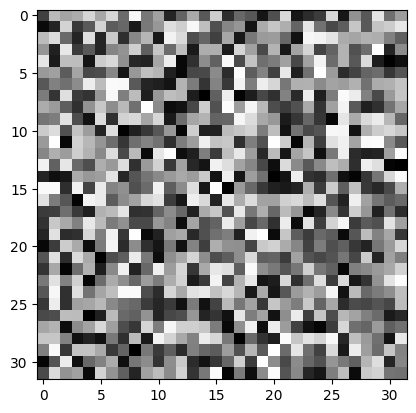

In [32]:
plt.imshow(input.squeeze().numpy(), cmap='gray')
plt.show()

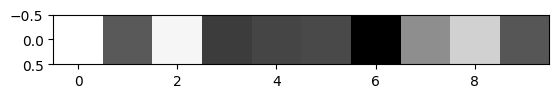

In [33]:
plt.imshow(output.detach().numpy(), cmap='gray')
plt.show()